# Contexto del Dataset

<!--
Alguna explicación del dataset. Lo que aqui se escriba se amplica en el reporte pero queda casi integro en la presentación

# Diccionario de Datos
   
Nota: las siglas _"rnped"_ y _"rnpedno"_ significan _"Red Nacional de Personas Desaparecidas"_ y _"Red Nacional de Personas Desaparecidas No Localizadas."_

In [3]:
from __future__ import annotations
from typing import Dict
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

dataset_path = "tot_reg_desap.csv"


def infer_statistical_type(series: pd.Series) -> str:
    """
    Clasifica el tipo estadístico de una variable:
    - numérico
    - categórico
    """
    if pd.api.types.is_numeric_dtype(series):
        return "numérico"
    return "categórico"


def infer_semantic_type(series: pd.Series, col_name: str) -> str:
    """
    Regresa una etiqueta de tipo de dato más legible para reporte.
    """
    if pd.api.types.is_integer_dtype(series):
        return "entero"
    if pd.api.types.is_float_dtype(series):
        return "flotante"
    if pd.api.types.is_bool_dtype(series):
        return "booleano"
    if pd.api.types.is_datetime64_any_dtype(series):
        return "fecha/hora"

    # Intento de detección de fecha si la columna viene como texto
    if "fecha" in col_name.lower():
        parsed = pd.to_datetime(series, errors="coerce", dayfirst=True)
        if parsed.notna().mean() > 0.7:
            return "fecha (texto parseable)"

    return "texto"


def explain_column(col: str):
    """
    Descripción semántica por nombre de columna.
    """
    c = col.strip().lower()

    dictionary: Dict[str, str] = {
        "dataset_id": "Identificador único del registro.",
        "nombrecompleto": "Nombre completo de la persona reportada como desaparecida/no localizada.",
        "rnpdno_json": "Presencia/coincidencia en RNPDNO (0/1).",
        "entidad_desap": "Entidad donde se reporta la desaparición/no localización.",
        "pre_rnped": "Indicador previo asociado a RNPED (0/1), usado para cruce/validación entre fuentes.",
        "rnped": "Presencia/coincidencia con registros RNPED (0/1).",
        "rnpdno_csv": "Presencia/coincidencia en RNPDNO en formato CSV (0/1).",
        "bg_1": "Bandera/indicador auxiliar de consistencia o disponibilidad de información (primer indicador).",
        "estatus_busqueda": "Estatus del proceso de búsqueda.",
        "bg_2": "Bandera/indicador auxiliar de consistencia o disponibilidad de información (segundo indicador).",
        "fub": "Folio Único de Búsqueda.",
        "dc_id": "Identificador de cruce o conciliación entre distintas fuentes (JSON/CSV/FUB).",
        "fecha_desap": "Fecha de desaparición o no localización reportada.",
    }

    if c in dictionary:
        return dictionary[c]

    if "fecha" in c:
        return "Campo de fecha asociado al registro."
    if "id" in c:
        return "Identificador del registro o de conciliación entre fuentes."
    if "estatus" in c:
        return "Estado o categoría del proceso asociado al registro."
    if "entidad" in c:
        return "Entidad geográfica/federativa asociada al registro."
    if "nombre" in c:
        return "Nombre o texto identificador de persona."
    if c.startswith("bg_"):
        return "Bandera/indicador binario auxiliar."


def build_data_dictionary(df: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for col in df.columns:
        series = df[col]
        non_null = series.dropna()
        n_unique = non_null.nunique()
        example_values = ", ".join(map(str, non_null.astype(str).unique()[:2]))
        semantic_type = infer_semantic_type(series, col)

        rows.append(
            {
                "Variable": col,
                "Descripcion": explain_column(col),
                "Tipo Dato (Pandas)": str(series.dtype),
                "Tipo Dato (Semantico)": semantic_type,
                "Tipo Estadistico": infer_statistical_type(series),
                "# No Nulos": int(series.notna().sum()),
                "# Nulos": int(series.isna().sum()),
                "# Únicos No Nulos": int(n_unique),
                "Ejemplos": example_values,
            }
        )

    return pd.DataFrame(rows)


df = pd.read_csv(dataset_path, low_memory=False)
# La primera columna del dataset no tiene un nombre asignado.
df = df.rename(columns={df.columns[0]: "dataset_id"})
data_dict = build_data_dictionary(df)
display(data_dict)

,Variable,Descripcion,Tipo Dato (Pandas),Tipo Dato (Semantico),Tipo Estadistico,# No Nulos,# Nulos,# Únicos No Nulos,Ejemplos
0,dataset_id,Identificador único del registro.,int64,entero,numérico,89720,0,89720,"1, 2"
1,nombrecompleto,Nombre completo de la persona reportada como d...,str,texto,categórico,89720,0,88513,"LUIS ADRIAN JUAREZ MORALES, ERNESTO ALONSO HER..."
2,rnpdno_json,Presencia/coincidencia en RNPDNO (0/1).,int64,entero,numérico,89720,0,2,"1, 0"
3,entidad_desap,Entidad donde se reporta la desaparición/no lo...,str,texto,categórico,89720,0,33,"QUERETARO, CHIHUAHUA"
4,pre_rnped,"Indicador previo asociado a RNPED (0/1), usado...",int64,entero,numérico,89720,0,2,"0, 1"
5,rnped,Presencia/coincidencia con registros RNPED (0/1).,int64,entero,numérico,89720,0,2,"0, 1"
6,rnpdno_csv,Presencia/coincidencia en RNPDNO en formato CS...,int64,entero,numérico,89720,0,2,"1, 0"
7,bg_1,Bandera/indicador auxiliar de consistencia o d...,int64,entero,numérico,89720,0,2,"0, 1"
8,estatus_busqueda,Estatus del proceso de búsqueda.,str,texto,categórico,62356,27364,9,"Con indicios / Ubicada, Se busca reportante"
9,bg_2,Bandera/indicador auxiliar de consistencia o d...,int64,entero,numérico,89720,0,2,"0, 1"


# Problemáticas a Resolver (Business Understanding)

<!--
Aqui falta ampliar el por que de estas preguntas?
-->

En resumidas cuentas, debemos analizar los registros de personas desaparecidas para identificar patrones relevantes que pueden apoyar la comprensión de este fenómeno. Lo anterior nos lleva a formular las siguientes preguntas para este dataset:

1. ¿Cuáles son las entidades con mayor incidencia de desapariciones?
2. ¿Cuál es la tendencia de desapariciones a lo largo del tiempo? ¿Aumentan o disminuyen los desaparecidos?
3. ¿Qué proporción de casos está activo vs. resuelto?
4. ¿Cuál es la tasa de resolución por entidad? ¿Hay entidades más efectivas que otras?

# Critérios de Éxito

- Se deben de identificar de forma clara las tendencias temporales y globales en el dataset.
- Es de gran importancia detectar zonas críticas para conocer donde se deben aplicar más esfuerzos en resolver estos casos.
- Al ser un dataset con muchas inconsistencias, debemos llegar a los resultados más interpretables posibles.

# Data Understanding

## Preparación del Entorno

In [4]:
df = pd.read_csv(dataset_path)  # lectura del dataset

print(f"Total de Filas: {df.shape[0]}")
print(f"Total de Columnas: {df.shape[1]}")

print(df.columns.to_list())  # ver las categorias de las columnas

# Periodo de fechas (1. ordenamos respecto a la fecha de desaparición, 2. Seleccionamos la primera y última)
df_ord_fechas = df.sort_values(by="fecha_desap").dropna()  # quitamos los NaN

primero_y_ultimo = df_ord_fechas.iloc[[0, -1]]
print("\nPrimera Fecha y última fecha:")
print(primero_y_ultimo["fecha_desap"])

# Imprimir head para analizar el significado de las entradas del dataset
df.head()

Total de Filas: 89720
Total de Columnas: 13
['Unnamed: 0', 'nombrecompleto', 'rnpdno_json', 'entidad_desap', 'pre_rnped', 'rnped', 'rnpdno_csv', 'bg_1', 'estatus_busqueda', 'bg_2', 'fub', 'DC_id', 'fecha_desap']

Primera Fecha y última fecha:
82335    01/01/1967
10573    31/12/2022
Name: fecha_desap, dtype: str


,Unnamed: 0,nombrecompleto,rnpdno_json,entidad_desap,pre_rnped,rnped,rnpdno_csv,bg_1,estatus_busqueda,bg_2,fub,DC_id,fecha_desap
0,1,LUIS ADRIAN JUAREZ MORALES,1,QUERETARO,0,0,1,0,NaN,0,NaN,"101 (json), 5673 (csv)",19/04/2023
1,2,ERNESTO ALONSO HERNANDEZ GUTIERREZ,1,QUERETARO,0,0,1,1,Con indicios / Ubicada,1,187731B1B-3302-4BE3-81D5-018CFB86A00B,"349 (json), 448 (csv), 187731B1B-3302-4BE3-81D...",12/07/2016
2,3,PIEDAD JESUS GUERRERO CHAVEZ,1,QUERETARO,0,0,1,1,Se busca reportante,1,122009919-199C-4B90-8462-935A6EDCE439,"732 (json), 14618 (csv), 122009919-199C-4B90-8...",26/09/2017
3,4,LORENZO MARTINEZ,1,QUERETARO,0,0,1,1,Se requieren datos de identidad,1,148436E49-364B-4663-847C-0338E23B2460,"1007 (json), 89640 (csv), 148436E49-364B-4663-...",17/03/2010
4,5,AGUSTINA OLVERA OCHOA,1,QUERETARO,0,0,1,1,NaN,0,NaN,"1013 (json), 57259 (csv)",04/06/2023


En base a lo anterior podemos observar que:

1. El dataset tiene 89720 filas y 13 columnas
2. El periodo de fechas cubierto está en el rango entre 1 de enero de 1967 hacia adelante. Aunque al ejecutar `df.head()` se muestra un valor máximo del 31 de Diciembre de 2012, en analisis manual se ve que hay informacíon posterior a esta fecha.
3. Hay muchas fechas en el dataset que no se logran tratar de manera automática como una fecha, si no que más bien aparecen como una cadena.
4. Cada entrada en el dataset corresponde a la información de una persona desaparecida. Entre lo más importante se encuentra el nombre, la entidad donde desaperecio, el estado de búsqueda y la fecha de desaparición.
5. Existen entrantadas duplicadas en el dataset, incluso hay casos en los que hay datos nulos como la falta del nombre o la fecha de desaparición.
6. Por todo lo anterior, debemos "pre-limpiar" los datos para que el procesamiento posterior tenga sentido.

## Pre-limpieza de Datos y Selección de Variables

Crearemos un dataset reducido en base a las variables que se mostrarán a continuación. Esto permitirá resolver interrogantes derivadas de las problemáticas previamente definidas:

- `nombrecompleto` : Es indispensable conocer el nombre de la persona a identificar para tener un registro unificado para cada quien.
- `entidad_desap`: ¿Cuál es la media y mediana de desaparecidos en cada entidad?, ¿Cuál entidad es la que más desaparecidos tiene?
- `fecha_desap`: ¿Cuál es la media y mediana de desapariciones por año?, ¿Cuál es el año con más desapariciones?
- `estatus_busqueda`: ¿Cuál es el estatus más común de las búsquedas? ¿Cuantos casos están resueltos? ¿Cuantos casos están inconclusos?

Luego, como las fechas en el dataset no aparecen como un tipo número (o mejor dicho, de tipo _fecha_), se deben aplicar una transformación a un tipo de dato `datetime` que nos permita manipular las fechas por dia, mes y año. Además, usaremos como variable derivada `año_desap` para analizar tendencias de desapariciones por año más adelante.

En cuanto a la limpieza inicial se refiere, se deben tratar los campos nulos y entradas duplicadas. Una impresión general del conjunto datos hace que notar que existen casos en los que existen datos nulos y/o faltantes nombre del la persona y/o fecha de desaparición. Nuestro acercamiento a estos valores será el siguiente.

1. Entradas con todos los campos iguales se deben eliminar pues estamos hablando de entradas repetidas para la misma persona.
2. Entradas con algún campo diferente deben tratarse como casos distintos.

Este procesamiento se ve de la siguiente manera:

In [5]:
# Nuevo dataset con columnas clave
df = pd.read_csv(dataset_path)
df_reducido = df[["nombrecompleto", "entidad_desap", "estatus_busqueda", "fecha_desap"]]

# Convertir fecha
df_reducido["fecha_desap"] = df_reducido["fecha_desap"].str.split(",").str[0]
df_reducido["fecha_desap"] = pd.to_datetime(df_reducido["fecha_desap"], dayfirst=True, errors="coerce")
df_reducido["anio_desap"] = df_reducido["fecha_desap"].dt.year

duplicados = df_reducido[df_reducido.duplicated()]

# Eliminar aquellos duplicados que tengan los 4 campos iguales (nombre, entidad, estatus, fecha)
df_reducido = df_reducido.drop_duplicates(subset=[
    'nombrecompleto',
    'entidad_desap',
    'estatus_busqueda',
    'fecha_desap'
])

duplicados = df_reducido[df_reducido.duplicated()]

print("Dataset reducido tras pre-procesamiento: \n\n", df_reducido)
print("\n\n Revisamos limpieza de duplicados correcta mostrando el dataframe de 'duplicados' vacío: \n\n")
print(duplicados)

Dataset reducido tras pre-procesamiento: 

                            nombrecompleto entidad_desap  \
0              LUIS ADRIAN JUAREZ MORALES     QUERETARO   
1      ERNESTO ALONSO HERNANDEZ GUTIERREZ     QUERETARO   
2            PIEDAD JESUS GUERRERO CHAVEZ     QUERETARO   
3                        LORENZO MARTINEZ     QUERETARO   
4                   AGUSTINA OLVERA OCHOA     QUERETARO   
...                                   ...           ...   
89715                   ABEL DIYARZA MEZA      TLAXCALA   
89716             PERLA SANCHEZ VELAZQUEZ      TLAXCALA   
89717           ARACELI SIMBRON HERNANDEZ      TLAXCALA   
89718                 KARLA ROMERO TEZMOL      TLAXCALA   
89719            ALEJANDRO REYES MARTINEZ      TLAXCALA   

                      estatus_busqueda fecha_desap  anio_desap  
0                                  NaN  2023-04-19      2023.0  
1               Con indicios / Ubicada  2016-07-12      2016.0  
2                  Se busca reportante  2017-09-26  

### Resultados de la Limpieza y Consideraciones Iniciales
Tras el procesamiento se identificaron 588 registros duplicados y posteriormente, tras la limpieza, esto se redujo a un dataframe vació, lo que nos indica que se eliminaron estas entradas correctamente. 

Sin embargo, dada la naturaleza de los datos, eso no significa que se hayan eliminado entradas en donde se este hablando de personas homónimas o con registros con información parcialmente coincidente. Por ejemplo, está la siguiente entrada en el dataframe reducido:

In [6]:
df_reducido[df_reducido['nombrecompleto'] == 'SERGIO SIMONS CARRILLO']

,nombrecompleto,entidad_desap,estatus_busqueda,fecha_desap,anio_desap
19320,SERGIO SIMONS CARRILLO,JALISCO,Denuncia confirmada,1973-07-15,1973.0
19935,SERGIO SIMONS CARRILLO,JALISCO,Denuncia confirmada,1973-07-24,1973.0
29329,SERGIO SIMONS CARRILLO,SE DESCONOCE,Denuncia confirmada,1973-07-15,1973.0
45844,SERGIO SIMONS CARRILLO,CIUDAD DE MEXICO,NaN,1973-07-15,1973.0


Otro punto a notar es que en este proceso también se encontraron registros sin nombre, los cuales no se borraron pues pueden representar
distintas personas reportadas en la misma fecha o casos con mismo estatus de búsqueda.

<!---
3. Cálculo de medidas con visualizaciones e interpretación

   * Medidas de localización (media, moda, mediana)

     Para este análisis tomaremos en cuenta variables numéricas las cuales se puede sacar información importante como:
   * 'entidad_desap': (¿Cuál es la media y mediana de desaparecidos en cada entidad?, ¿Cuál entidad es la que más aparece (moda)?)
   * 'fecha_desap': (¿Cuál es la media y mediana de desapariciones por año?, ¿Cuál es el año con más desapariciones (moda)?)
   * 'estatus_busqueda': 

In [7]:
def resumen_variable(serie, nombre):
    print(f"Variable en análisis: {nombre}")

    # Frecuencias
    print("\nFrecuencias:")
    print(serie.value_counts(dropna=False).head(10))

    # Moda (aplica a todas)
    moda = serie.mode()
    print("\nModa:")
    print(moda)

    # Si es numérica
    if pd.api.types.is_numeric_dtype(serie):
        print("\nMedia:", serie.mean())
        print("Mediana:", serie.median())

    # Si es fecha
    elif pd.api.types.is_datetime64_any_dtype(serie):
        print("\nFecha mínima:", serie.min())
        print("Fecha máxima:", serie.max())
        print("Mediana:", serie.median())

        # Media en fechas (opcional)
        try:
            print("Media (timestamp):", serie.mean())
        except:
            pass

    else:
        print("\nMedia: No aplica (variable categórica)")
        print("Mediana: No aplica (variable categórica)")

# LIMPIEZA DE DATOS
df["fecha_desap"] = pd.to_datetime(
    df["fecha_desap"],
    format="%d/%m/%Y",
    errors="coerce"
)

# ANALISIS
resumen_variable(df["entidad_desap"], "entidad_desap")
resumen_variable(df["estatus_busqueda"], "estatus_busqueda")
resumen_variable(df["fecha_desap"], "fecha_desap")

# CONTEO POR AÑO
df["anio"] = df["fecha_desap"].dt.year
resumen_variable(df["anio"], "anio")

Variable en análisis: entidad_desap

Frecuencias:
entidad_desap
TAMAULIPAS          11897
ESTADO DE MEXICO    10963
VERACRUZ             6043
SINALOA              5426
MICHOACAN            5126
JALISCO              4709
NUEVO LEON           4622
SONORA               4340
CHIHUAHUA            4144
GUERRERO             4129
Name: count, dtype: int64

Moda:
0    TAMAULIPAS
Name: entidad_desap, dtype: str

Media: No aplica (variable categórica)
Mediana: No aplica (variable categórica)
Variable en análisis: estatus_busqueda

Frecuencias:
estatus_busqueda
NaN                                                        27364
Se busca reportante                                        22863
Se requieren datos de identidad                            18425
Con indicios / Ubicada                                     12622
Denuncia confirmada                                         8408
Se requieren datos de identidad, Se busca reportante          20
Se requieren datos de identidad, Con indicios / Ubicad

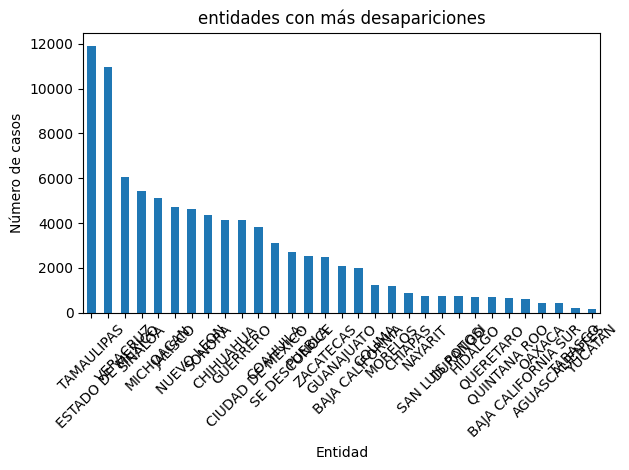

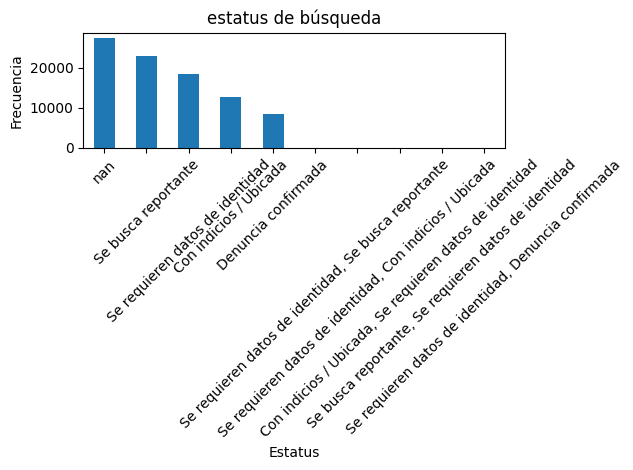

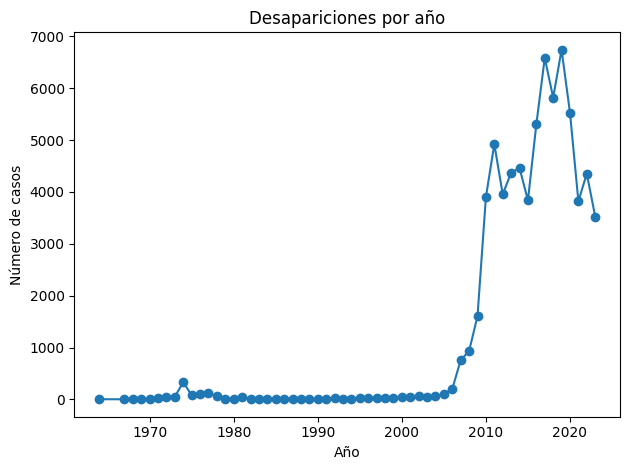

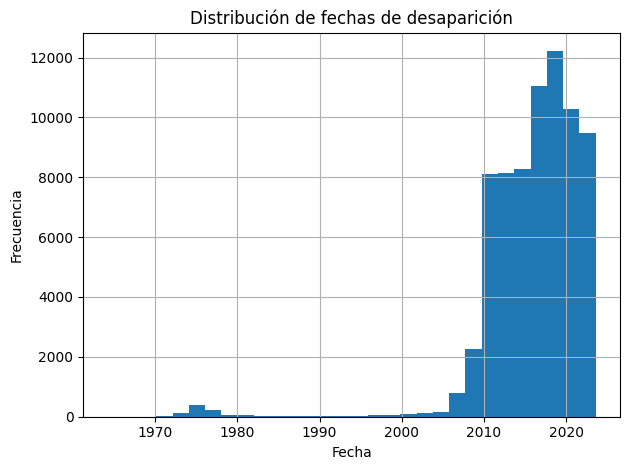

In [8]:
# =========================
# DISTRIBUCIÓN: entidad_desap
# =========================
top_entidades = df["entidad_desap"].value_counts().head(31)

plt.figure()
top_entidades.plot(kind="bar")
plt.title("entidades con más desapariciones")
plt.xlabel("Entidad")
plt.ylabel("Número de casos")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# =========================
# DISTRIBUCIÓN: estatus_busqueda
# =========================
top_estatus = df["estatus_busqueda"].value_counts(dropna=False).head(10)

plt.figure()
top_estatus.plot(kind="bar")
plt.title("estatus de búsqueda")
plt.xlabel("Estatus")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# =========================
# DISTRIBUCIÓN TEMPORAL
# =========================
df["anio"] = df["fecha_desap"].dt.year

conteo_anual = df["anio"].value_counts().sort_index()

plt.figure()
conteo_anual.plot(kind="line", marker="o")
plt.title("Desapariciones por año")
plt.xlabel("Año")
plt.ylabel("Número de casos")
plt.tight_layout()
plt.show()

# =========================
# HISTOGRAMA DE FECHAS
# =========================
plt.figure()
df["fecha_desap"].dropna().hist(bins=30)
plt.title("Distribución de fechas de desaparición")
plt.xlabel("Fecha")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

In [9]:
# =========================
# FUNCION DE VARIABILIDAD
# =========================
def medidas_variabilidad(serie, nombre):
    print("\n=========================")
    print(f"VARIABLE: {nombre}")
    print("=========================")

    # Eliminar nulos
    #serie = serie.dropna()

    # Si es fecha convertir a numérico (timestamp)
    if pd.api.types.is_datetime64_any_dtype(serie):
        serie = serie.astype("int64")  # nanosegundos

    # Solo aplicar a datos numéricos
    if pd.api.types.is_numeric_dtype(serie):

        if len(serie) == 0:
            print("Sin datos suficientes")
            return

        rango = serie.max() - serie.min()
        varianza = serie.var(ddof=1)  # muestral
        desviacion = serie.std(ddof=1)
        media = serie.mean()

        # Coeficiente de variación
        if media != 0:
            coef_var = desviacion / media
        else:
            coef_var = np.nan

        print(f"Rango: {rango}")
        print(f"Varianza muestral: {varianza}")
        print(f"Desviación estándar muestral: {desviacion}")
        print(f"Coeficiente de variación: {coef_var}")

    else:
        print("No aplica (variable no numérica)")

# =========================
# VARIABLES DE INTERÉS
# =========================

medidas_variabilidad(df["fecha_desap"], "fecha_desap")

# analizar el año
df["anio"] = df["fecha_desap"].dt.year
medidas_variabilidad(df["anio"], "anio")


# =========================
# AUTOMÁTICO
# =========================

print("\n\n=== ANALISIS AUTOMATICO ===")
for col in df.columns:
    medidas_variabilidad(df[col], col)


VARIABLE: fecha_desap
Rango: -9221680929654775808
Varianza muestral: 1.3391600472573407e+37
Desviación estándar muestral: 3.659453575682223e+18
Coeficiente de variación: -2.029296850397153

VARIABLE: anio
Rango: 59.0
Varianza muestral: 40.24258068339376
Desviación estándar muestral: 6.34370401921415
Coeficiente de variación: 0.0031474199155539324


=== ANALISIS AUTOMATICO ===

VARIABLE: Unnamed: 0
Rango: 89719
Varianza muestral: 670814010.0
Desviación estándar muestral: 25900.077413011724
Coeficiente de variación: 0.5773470517049905

VARIABLE: nombrecompleto
No aplica (variable no numérica)

VARIABLE: rnpdno_json
Rango: 1
Varianza muestral: 0.09661867045857551
Desviación estándar muestral: 0.31083543951514847
Coeficiente de variación: 0.3486106606827561

VARIABLE: entidad_desap
No aplica (variable no numérica)

VARIABLE: pre_rnped
Rango: 1
Varianza muestral: 0.014463689466428736
Desviación estándar muestral: 0.12026507999593537
Coeficiente de variación: 8.193001501317632

VARIABLE: rn

/var/folders/yq/5vgkt53s6sn4yz076nh0n66m0000gn/T/ipykernel_14065/296089168.py:23: RuntimeWarning: overflow encountered in scalar subtract
  rango = serie.max() - serie.min()
/var/folders/yq/5vgkt53s6sn4yz076nh0n66m0000gn/T/ipykernel_14065/296089168.py:23: RuntimeWarning: overflow encountered in scalar subtract
  rango = serie.max() - serie.min()


## Análisis de Frecuencias

Veamos ahora el análisis de frecuencias del dataset. Esto se hace de antemano para tener disponibles estos valores para las medidas de localización, variabilidad y heterogeneidad.

In [10]:
columnas_interes = ['entidad_desap', 'estatus_busqueda', 'anio_desap']
frecuencias = {}

for col in columnas_interes:
    print(f"\nFrecuencia de {col}:")
    print(df_reducido[col].value_counts(dropna=False))

for col in columnas_interes:
    frecuencias[col] = df_reducido[col].value_counts(dropna=False)


Frecuencia de entidad_desap:
entidad_desap
TAMAULIPAS             11786
ESTADO DE MEXICO       10935
VERACRUZ                5965
SINALOA                 5366
MICHOACAN               5072
JALISCO                 4692
NUEVO LEON              4607
SONORA                  4324
CHIHUAHUA               4130
GUERRERO                4069
CIUDAD DE MEXICO        3833
COAHUILA                3081
SE DESCONOCE            2710
PUEBLA                  2502
ZACATECAS               2467
GUANAJUATO              2056
BAJA CALIFORNIA         1994
COLIMA                  1232
MORELOS                 1179
CHIAPAS                  889
NAYARIT                  755
SAN LUIS POTOSI          748
DURANGO                  733
HIDALGO                  716
QUERETARO                707
QUINTANA ROO             632
BAJA CALIFORNIA SUR      599
OAXACA                   434
AGUASCALIENTES           409
TABASCO                  199
YUCATAN                  173
CAMPECHE                  72
TLAXCALA                  66

# Medidas de Localización

Ocuparemos las recientemente calculadas frecuencias obtenidas de las variables seleccionadas para obtener la moda, media y mediana de las mismas
y asi llegar a una interpretacíon de estos valores. 

In [11]:
frecuencias_entidad = df_reducido['entidad_desap'].value_counts()
frecuencias_anio = df_reducido['anio_desap'].value_counts().sort_index()
frecuencias_estatus = df_reducido['estatus_busqueda'].value_counts()

media_entidades = frecuencias_entidad.mean()
print("La media de desapariciones por entidad es: " + str(media_entidades))

media_anual = frecuencias_anio.mean()
print("La media de desapariciones por anio es: " + str(media_anual))

mediana_anio = df_reducido['anio_desap'].median()
print("La mediana de los anios del dataset es: " + str(mediana_anio))

moda_anio = df_reducido['anio_desap'].mode()
print("La moda de los anios del dataset es: " + str(moda_anio))

moda_estado = df_reducido['entidad_desap'].mode()
print("La moda de los estados del dataset es: " + str(moda_estado))

moda_estatus = df_reducido['estatus_busqueda'].mode()
print("La moda de los estados de busqueda del dataset es: " + str(moda_estatus))

La media de desapariciones por entidad es: 2700.969696969697
La media de desapariciones por anio es: 1417.5689655172414
La mediana de los anios del dataset es: 2016.0
La moda de los anios del dataset es: 0    2007.0
Name: anio_desap, dtype: float64
La moda de los estados del dataset es: 0    TAMAULIPAS
Name: entidad_desap, dtype: str
La moda de los estados de busqueda del dataset es: 0    Se busca reportante
Name: estatus_busqueda, dtype: str


## Visualización

Esto nos lleva las siguientes gráficas. 

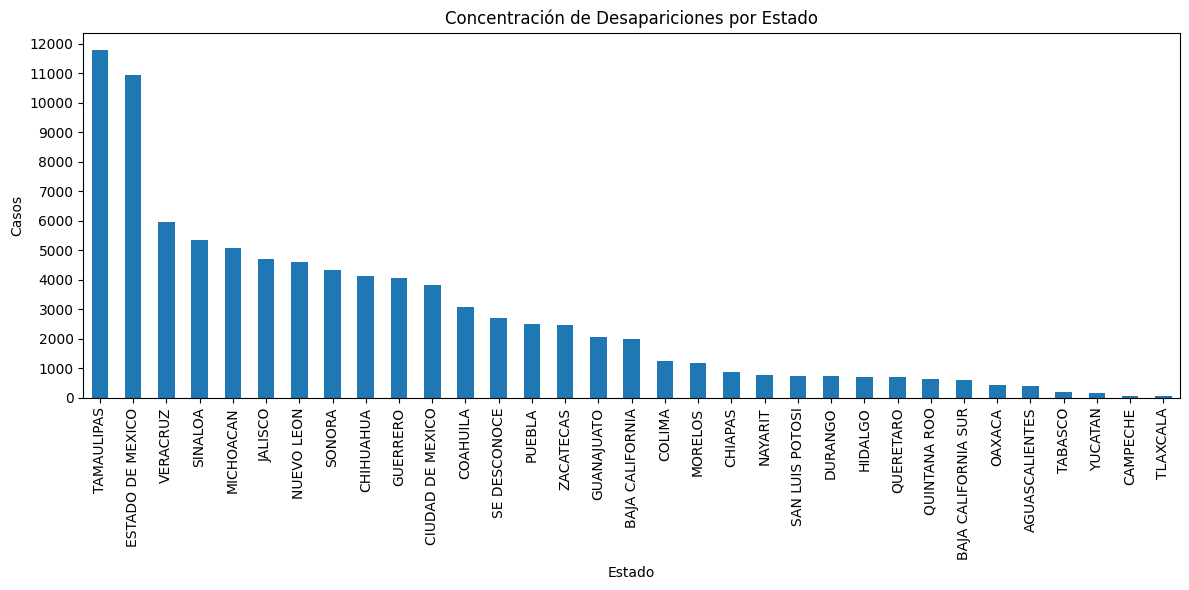

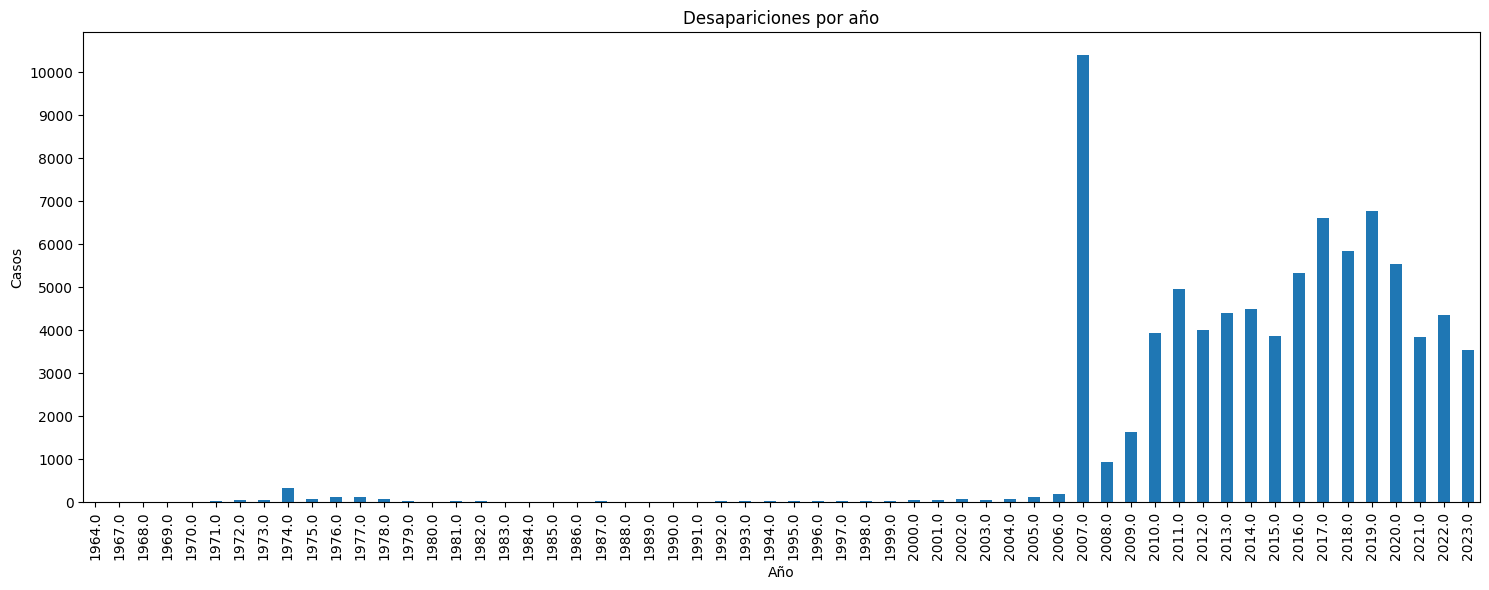

In [17]:
# Grafica por Estado

plt.figure(figsize=(12, 6))
frecuencias_entidad.plot(kind='bar')  
plt.title('Concentración de Desapariciones por Estado')
plt.xlabel('Estado')
plt.ylabel('Casos')
plt.xticks(rotation=90)
plt.locator_params(axis='y', nbins=20)
plt.tight_layout()
plt.show()

# Gráfica por Año
plt.figure(figsize=(15, 6))
frecuencias_anio.plot(kind='bar')
plt.title('Desapariciones por año')
plt.xlabel('Año')
plt.ylabel('Casos')
plt.xticks(rotation=90)
plt.locator_params(axis='y', nbins=20)
plt.tight_layout()
plt.show()

## Interpretaciones

### Desapariciones por Entidad 

La media de desapariciones por entidad es de aprox. 2700 personas. Esto implica que si las desapariciones estuvieran distribuidas de manera uniforme, cada estado tendría esa cantidad de casos. La realidad es distinta pero no menos triste: existen estados muy por encima de la media y otros muy por debajo.

El principal dato destacable de estos valores, por entidad, es que la moda indica que Tamaulipas es el estado con mayor número de desapariciones registradas.

Un análisis adicional interesante sería relacionar la cantidad de desapariciones con la población de cada entidad, lo que permitiría obtener una visión más precisa sobre la situación de inseguridad.

### Desapariciones por Año

La media de desapariciones por año es de aprox. 1417 personas. Esto indica que, bajo una distribución uniforme, cada año tendría esa cantidad de casos. No obstante, hay años con muy baja concentración de desapariciones y otros que concentran una gran proporción del total.

Otros datos destacables por año son los siguientes: 

- La mediana del año 2016 indica que el 50% de las desapariciones ocurrieron antes de ese año y el otro 50% después. Es decir, 50% entre 1964 y 2016 y la otra mitad hacia el 2023. Esto representa un dato preocupante, ya que sugiere un incremento significativo de las desapariciones en años recientes.
- La moda recae totalmente en el año 2007, es el año con mayor número de desapariciones registradas.

Otro dato que sale a raíz de estos cálculos es que la moda del estado de búsqueda más común es _"se busca reportante"_. Este dato es igual de alarmante que los anteriores. Los reportes de desaparición que se encuentran en este estado tienen la particularidad de que no sabe incluso quien reportó a la persona desaparecida. 

# Medidas de Variabilidad

In [18]:
resumen_varianzas_anio = pd.DataFrame({
    "media": [df_reducido["anio_desap"].mean()],
    "varianza": [df_reducido["anio_desap"].var()],
    "desv_std": [df_reducido["anio_desap"].std()],
    "min": [df_reducido["anio_desap"].min()],
    "q1": [df_reducido["anio_desap"].quantile(0.25)],
    "mediana": [df_reducido["anio_desap"].median()],
    "q3": [df_reducido["anio_desap"].quantile(0.75)],
    "max": [df_reducido["anio_desap"].max()],
})

resumen_varianzas_anio["rango"] = resumen_varianzas_anio["max"] - resumen_varianzas_anio["min"]
resumen_varianzas_anio["IQR"] = resumen_varianzas_anio["q3"] - resumen_varianzas_anio["q1"]
resumen_varianzas_anio["CV"] = resumen_varianzas_anio["desv_std"] / resumen_varianzas_anio["media"]
resumen_varianzas_anio

,media,varianza,desv_std,min,q1,mediana,q3,max,rango,IQR,CV
0,2014.516681,43.036292,6.560205,1964.0,2011.0,2016.0,2019.0,2023.0,59.0,8.0,0.003256


## Visualización e Interpretación

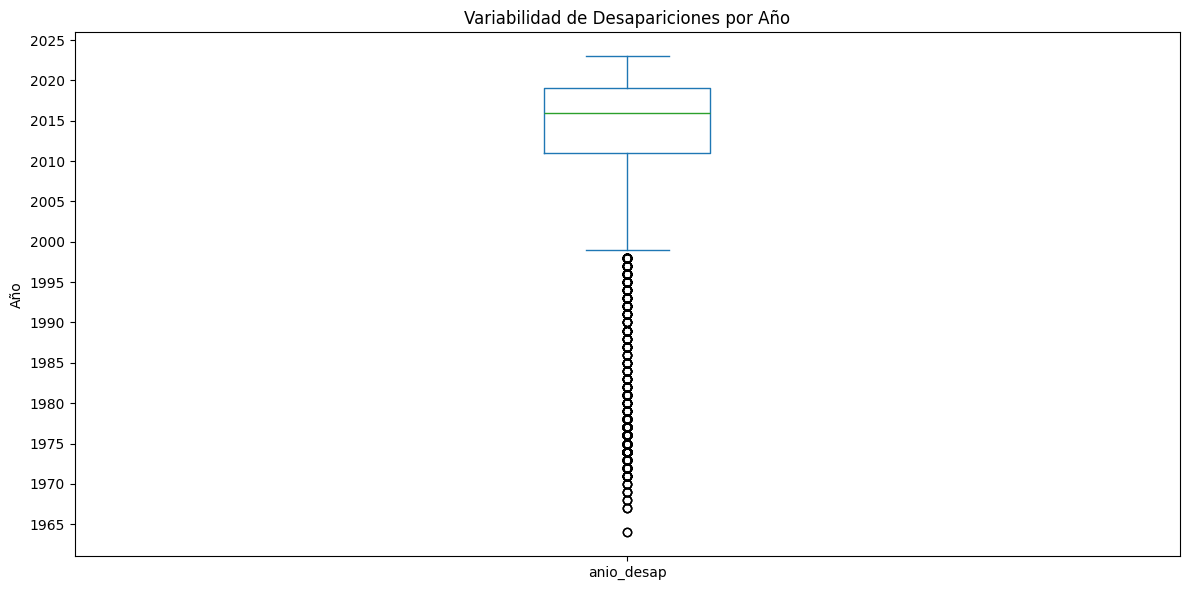

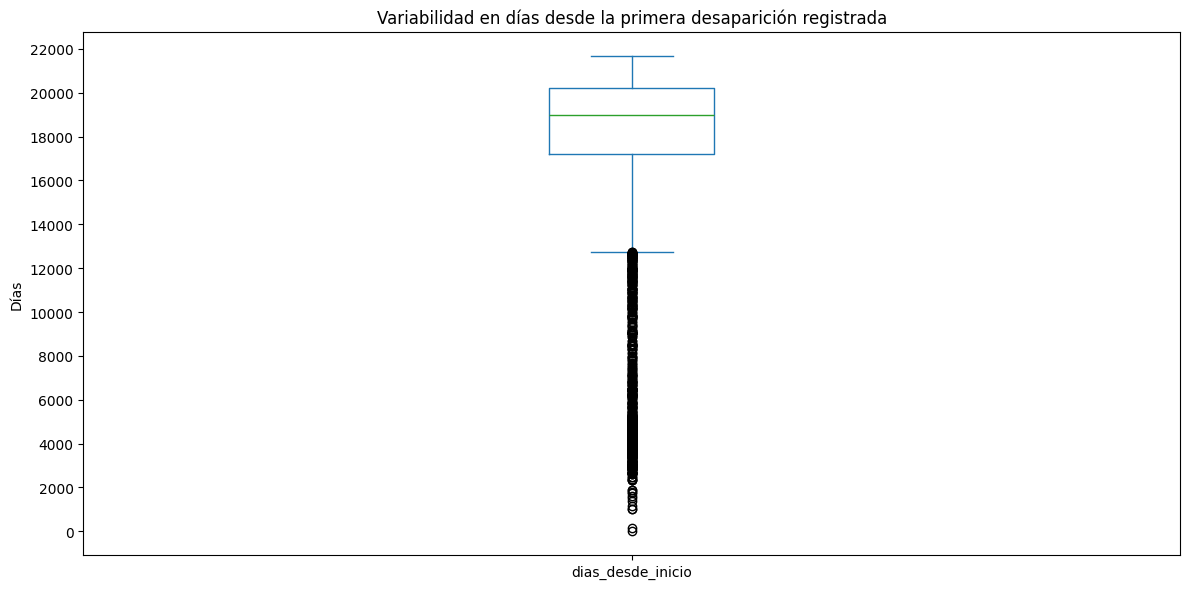

In [19]:
df_reducido["dias_desde_inicio"] = (df_reducido["fecha_desap"] - df_reducido["fecha_desap"].min()).dt.days

# Boxplot de Año de Desaparición
plt.figure(figsize=(12, 6))
df_reducido["anio_desap"].dropna().plot(kind="box")
plt.title("Variabilidad de Desapariciones por Año")
plt.ylabel("Año")
plt.locator_params(axis='y', nbins=20)
plt.tight_layout()
plt.show()

# Boxplot de Dias desde la Desparación
plt.figure(figsize=(12, 6))
df_reducido["dias_desde_inicio"].dropna().plot(kind="box")
plt.title("Variabilidad en días desde la primera desaparición registrada")
plt.ylabel("Días")
plt.locator_params(axis='y', nbins=20)
plt.tight_layout()
plt.show()

En base a estas gráficas podemos concluir que al menos el 50% de los casos de desapariciones se concentran entre los 2010 y 2020.  Como se había concluido previamente, la mediana de los casos de desaparición se encuentra alrededor del año 2016.

# Medidas de Heterogeneidad

In [21]:
def entropia_shannon(serie):
    p = serie.value_counts(normalize=True, dropna=True)
    return -np.sum(p * np.log(p))

def indice_gini(array):
    array = array.dropna().values
    if len(array) == 0:
        return np.nan
    array = np.sort(array)
    n = len(array)
    return (np.sum((2 * np.arange(1, n+1) - n - 1) * array)) / (n * np.sum(array))

heterogeneidad = pd.DataFrame({
    "Variable": ["entidad_desap", "estatus_busqueda", "anio_desap"],
    "Métrica": ["Shannon", "Shannon", "Gini"],
    "Valor": [
        entropia_shannon(df_reducido["entidad_desap"]),
        entropia_shannon(df_reducido["estatus_busqueda"]),
        indice_gini(df_reducido["anio_desap"])
    ]
})

heterogeneidad

,Variable,Métrica,Valor
0,entidad_desap,Shannon,3.021391
1,estatus_busqueda,Shannon,1.323578
2,anio_desap,Gini,0.001617


## Interpretación

| Variable         | Nivel de Heterogeneidad  | Interpretación                               |
|------------------|----------------|---------------------------------------------  |
| entidad_desap    | Alta           | La desaparición de personas es un fenómeno distribuido geográficamente.         |
| estatus_busqueda | Media - baja     | Concentración en pocos tipos de estatus. Esto significa que la mayoria de casos cae en pocas categorías.       |
| anio_desap       | Muy baja | La cantidad de desaparecidos se distribuye de manera uniforme a lo largo del tiempo.    |

# Medidas de Concentración

# Correlación del Dataset

# Estado Final del Dataset

In [27]:
faltantes = df_reducido.isnull().sum()
porcentaje = (faltantes / len(df)) * 100

faltantes_df = pd.DataFrame({
    "faltantes": faltantes,
    "porcentaje": porcentaje
}).sort_values(by="porcentaje", ascending=False)

duplicados = df_reducido.duplicated().sum()
print(faltantes_df, "\nNúmero de duplicados:", duplicados)

                   faltantes  porcentaje
estatus_busqueda       27198   30.314311
fecha_desap             6913    7.705082
anio_desap              6913    7.705082
dias_desde_inicio       6913    7.705082
entidad_desap              0    0.000000
nombrecompleto             0    0.000000 
Número de duplicados: 0


Al inicio de este archivo se realizo una limpieza preliminar de los datos para poder manipularlos. Recordemos uno de los criterios que se utilizaron en su momento fue quedarnos unicamente con las columnas `nombrecompleto`, `entidad_desap`, `fecha_desap`, y `estatus_busqueda` para poder trabajar con valores que nos ayudaran a contestar las preguntas planteadas al inicio.

Estos ajustes, sumados a los resultados anteriores, nos lleva a las siguientes conclusiones sobre el estado original de los datos:

- Trístemente, las columnas `estatus_busqueda` y `fecha_desap` son la que más valores nulos contienen.
- Esto coincide con la averiguación inicial de que este dataset es una mezcla de 

Finalmente, la exportación del dataset modificado como archivo `.csv` se hace la siguiente manera:

In [29]:
df_reducido.to_csv("tot_reg_desap_modificado.csv", sep=",", index=False, encoding='utf-8')